# 02 — Exploratory Data Analysis
Credit Card Fraud Detection

Mục tiêu: đi sâu hơn Data Understanding — so sánh phân phối feature giữa
Class=0 (legit) và Class=1 (fraud) để tìm feature nào phân tách 2 nhóm tốt nhất.
Đây là input trực tiếp cho quyết định Feature Engineering ở Giai đoạn 2.

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print(f"Shape: {df.shape}")

feature_cols = [c for c in df.columns if c not in ['Class']]
v_cols = [c for c in df.columns if c.startswith('V')]

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Shape: (284807, 31)


## 1. Histogram — `Amount` và `Time` theo Class

So sánh trực tiếp phân phối giữa fraud và legit. Dùng log-scale cho `Amount`
vì đã biết từ notebook trước là lệch phải mạnh.

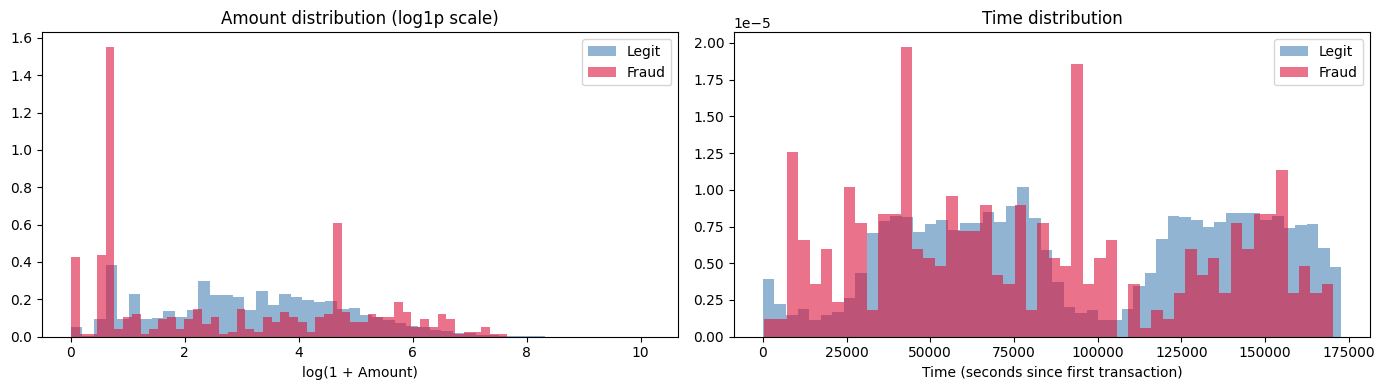

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount: log scale để nhìn rõ phân phối (không sửa data, chỉ đổi trục hiển thị)
axes[0].hist(np.log1p(df[df['Class']==0]['Amount']), bins=50, alpha=0.6, label='Legit', density=True, color='steelblue')
axes[0].hist(np.log1p(df[df['Class']==1]['Amount']), bins=50, alpha=0.6, label='Fraud', density=True, color='crimson')
axes[0].set_title('Amount distribution (log1p scale)')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()

# Time: xem có pattern theo thời gian không (Time tính bằng giây, tổng ~2 ngày dữ liệu)
axes[1].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.6, label='Legit', density=True, color='steelblue')
axes[1].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.6, label='Fraud', density=True, color='crimson')
axes[1].set_title('Time distribution')
axes[1].set_xlabel('Time (seconds since first transaction)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Cách đọc:** nếu 2 phân phối (xanh vs đỏ) chồng lên nhau gần như hoàn toàn →
feature đó yếu, không phân tách được fraud/legit. Nếu tách rời rõ rệt → feature mạnh.

Với `Time`: dữ liệu trải dài ~2 ngày, nên thường sẽ thấy pattern theo giờ trong ngày
(giao dịch giảm về đêm). Nếu fraud không theo pattern đó (xảy ra đều bất kể giờ nào)
→ đây có thể là một tín hiệu hữu ích (gợi ý tạo feature "giờ trong ngày" ở Feature Engineering).

**Hình 1 (Amount):**
Chưa hẳn "tách rời rõ" theo nghĩa 2 vùng giá trị không chồng lấn, nhìn kỹ thì cả 2 phân phối đều trải dài gần hết trục X (0 đến ~8), tức là range giá trị amount của fraud và legit chồng lấn nhau phần lớn.

Cái tách biệt ở đây là hình dạng phân phối:
- fraud có **2 đỉnh nhọn rõ rệt** (một đỉnh quanh log≈0.7, tức amount rất nhỏ ~1; một đỉnh quanh log≈4.7, tức amount ~100), còn **legit trải đều hơn**, không có đỉnh nhọn.
- Đây là tín hiệu có ích nhưng yếu-vừa, không phải kiểu "cứ amount > X là chắc chắn fraud". Amount một mình không đủ để phân loại tốt, cần kết hợp với các feature V khác.

**Hình 2 (Time):**

- Trục Y là mật độ xác suất (density), vì code dùng `density=True` để chuẩn hóa cho 2 nhóm Legit/Fraud so sánh được công bằng (số lượng fraud quá ít nếu không chuẩn hóa sẽ không nhìn thấy gì trên biểu đồ). Số 1e-5 ở góc trên là đơn vị scale của trục Y.

- Trục X là thời gian — Time tính bằng giây kể từ giao dịch đầu tiên, tổng dữ liệu trải dài ~172,800 giây = đúng 2 ngày.

**Đọc pattern:**

phần màu xanh (Legit) có 2 "gò" rõ rệt với 2 vùng trũng xen giữa (khoảng 0–25,000 và 85,000–110,000) — đây chính là ban đêm của mỗi ngày (ít giao dịch hợp lệ hơn vì người ta ngủ).

Cái đáng chú ý: phần đỏ (Fraud) lại có đỉnh nhô cao đúng vào những vùng trũng đó (gần giây 0 và gần giây ~95,000) — tức là fraud xảy ra tỷ lệ cao bất thường vào ban đêm, khi hoạt động giao dịch bình thường thấp.

Đây là insight thật, đáng đưa vào Feature Engineering: **tạo feature "giờ trong ngày" từ Time ((Time % 86400) / 3600) có thể giúp model rất nhiều.**

## 2. Boxplot — so sánh `Amount` theo Class

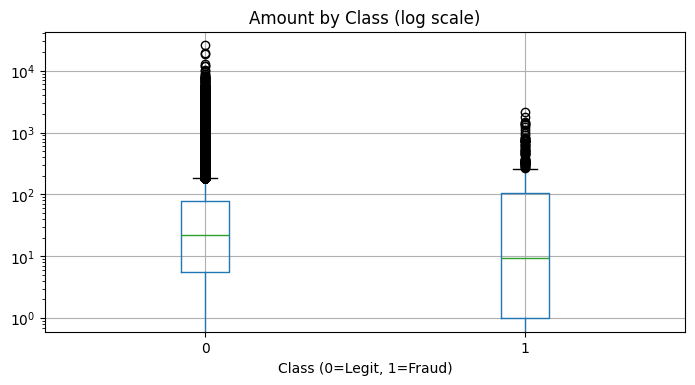

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='Amount', by='Class', ax=ax)
ax.set_yscale('log')  # log scale vì Amount lệch mạnh
ax.set_title('Amount by Class (log scale)')
plt.suptitle('')
plt.xlabel('Class (0=Legit, 1=Fraud)')
plt.show()

df.groupby('Class')['Amount'].describe()

Amount: fraud thiên về 2 cực (nhiều giao dịch rất nhỏ + vài giao dịch lớn), median fraud thấp hơn legit rõ rệt → cần log-transform

## 3. Phân tích các feature `V1`-`V28`

Với 28 feature đã PCA-transform, không thể nhìn từng cái một cách hiệu quả bằng mắt.
Cách làm chuẩn: tính **khác biệt phân phối giữa 2 class cho từng feature** (ví dụ
bằng độ lệch trung bình chuẩn hóa), xếp hạng, rồi chỉ vẽ chi tiết top feature mạnh nhất.

Top 10 feature phân tách fraud/legit mạnh nhất:
V17    7.861863
V14    7.285436
V12    6.275236
V10    5.222673
V16    4.732777
V3     4.646614
V7     4.509253
V11    3.729500
V4     3.213497
V18    2.684633
dtype: float64


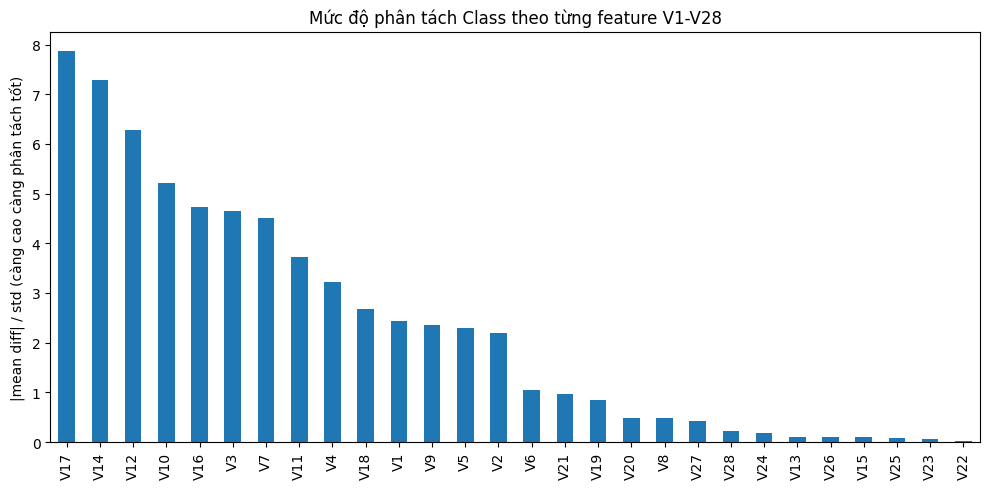

In [4]:
# Đo mức phân tách của từng feature: |mean(fraud) - mean(legit)| / std chung
separation_scores = {}
for col in v_cols:
    mean_legit = df[df['Class']==0][col].mean()
    mean_fraud = df[df['Class']==1][col].mean()
    pooled_std = df[col].std()
    separation_scores[col] = abs(mean_fraud - mean_legit) / pooled_std

sep_df = pd.Series(separation_scores).sort_values(ascending=False)
print("Top 10 feature phân tách fraud/legit mạnh nhất:")
print(sep_df.head(10))

plt.figure(figsize=(10, 5))
sep_df.plot(kind='bar')
plt.title('Mức độ phân tách Class theo từng feature V1-V28')
plt.ylabel('|mean diff| / std (càng cao càng phân tách tốt)')
plt.tight_layout()
plt.show()

Top feature mạnh nhất: V17, V14, V12, V10, V16 (khớp cả 2 phương pháp — separation score và correlation)

V1-V28 gần như không tương quan lẫn nhau (đúng tính chất PCA) → không lo multicollinearity

**Đây là bước quan trọng nhất của notebook này** — kết quả `sep_df` cho biết feature
nào (trong 28 feature ẩn danh) có khả năng dự đoán fraud mạnh nhất. Danh sách top này
sẽ được đối chiếu lại với Feature Importance / SHAP ở Giai đoạn 6 (Explainability) —
nếu 2 danh sách khớp nhau, đó là bằng chứng model đang học đúng tín hiệu thật,
không phải học nhiễu.

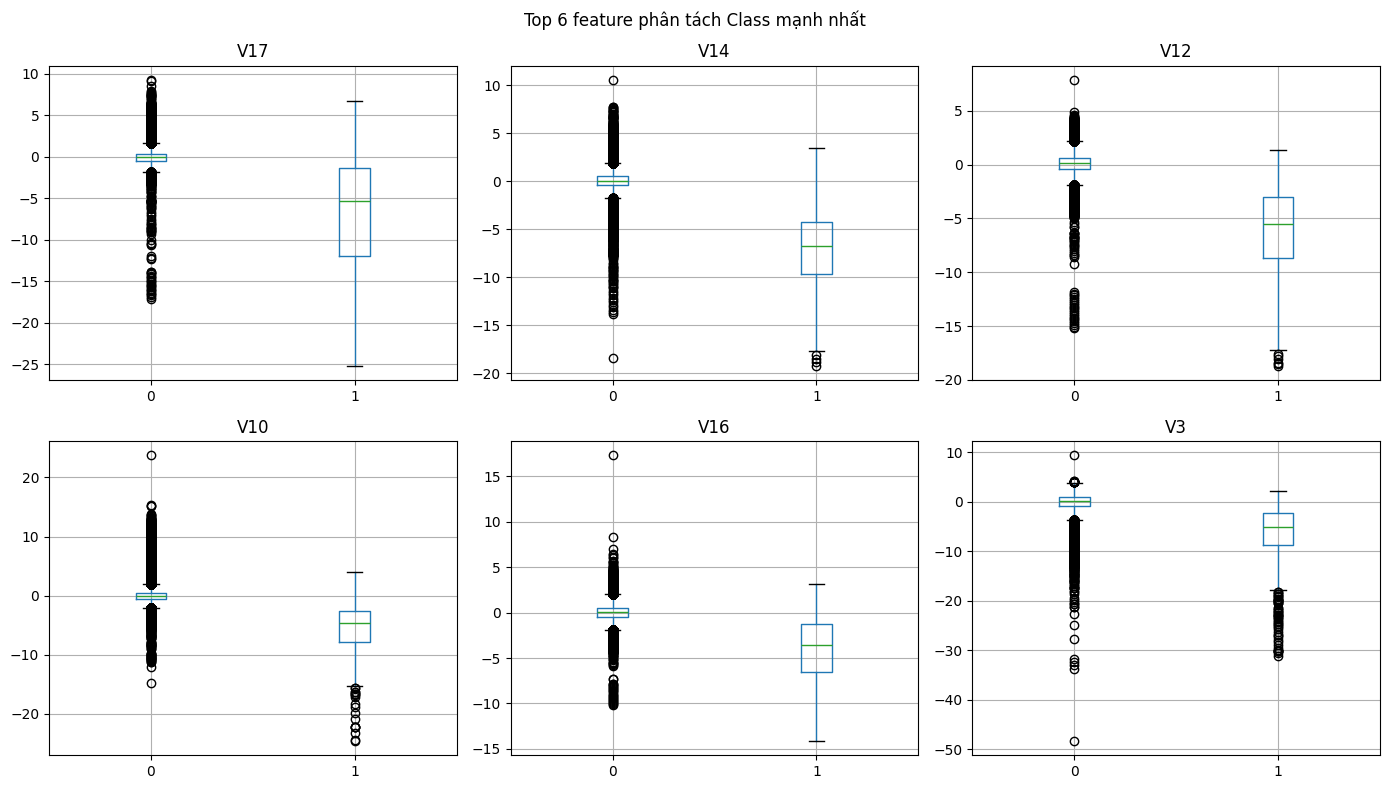

In [5]:
# Vẽ chi tiết boxplot cho top 6 feature phân tách mạnh nhất
top_features = sep_df.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), top_features):
    df.boxplot(column=col, by='Class', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Top 6 feature phân tách Class mạnh nhất')
plt.tight_layout()
plt.show()

## 4. Correlation

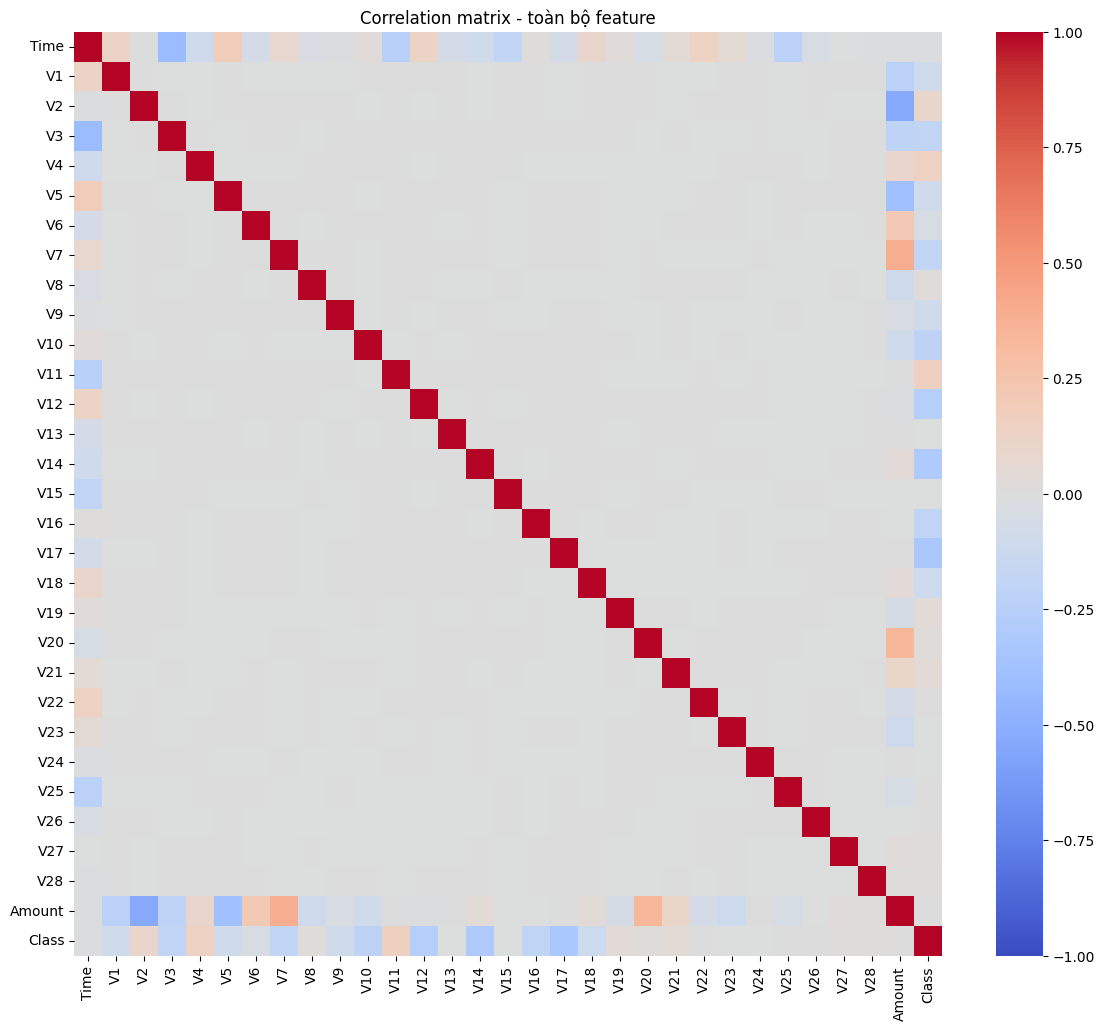

In [6]:
corr = df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix - toàn bộ feature')
plt.show()

nhìn cột Class trong heatmap, các ô xanh đậm nhất (tương quan âm mạnh) đúng là V17, V14, V12, V10, V16 — khớp gần như hoàn toàn với top 5 của separation score

In [7]:
# Correlation riêng với Class, xếp hạng
class_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Top 10 feature tương quan mạnh nhất với Class:")
print(class_corr.head(10))

Top 10 feature tương quan mạnh nhất với Class:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


**Lưu ý:** vì `V1`-`V28` là PCA components, về lý thuyết chúng **không tương quan
với nhau** (đó là đặc tính của PCA) — nếu heatmap cho thấy các cặp V-V gần như bằng 0,
đó là điều đúng, không phải lỗi. Chỉ cần quan tâm cột/hàng tương quan với `Class`
và với `Amount`/`Time` (2 cột duy nhất không qua PCA).

Danh sách `class_corr` nên khớp phần lớn với `sep_df` ở bước 3 — nếu lệch nhiều,
cần xem lại (correlation là quan hệ tuyến tính, còn separation score ở trên không
giả định tuyến tính, nên có thể có khác biệt nhỏ, đặc biệt với feature có quan hệ phi tuyến).

## 5. Kết luận EDA

Điền lại sau khi chạy (số liệu + feature name thật của mày):

- `Amount`: fraud có xu hướng amount ___ hơn legit; cần log-transform trước khi
  đưa vào model tuyến tính (Logistic Regression)
- `Time`: có/không có pattern rõ rệt khác biệt giữa fraud/legit theo giờ trong ngày
- Top feature phân tách mạnh nhất: liệt kê từ `sep_df` (vd: V14, V4, V12, V10...)
- Correlation với `Class`: liệt kê từ `class_corr`, đối chiếu với `sep_df`
- V1-V28 gần như không tương quan với nhau (đúng theo tính chất PCA) → ít lo
  multicollinearity khi dùng Logistic Regression
- Gợi ý cho Feature Engineering (Giai đoạn 2):
  - Log-transform `Amount`
  - Có thể thử tạo feature giờ trong ngày từ `Time`
  - Cân nhắc chỉ giữ/nhấn mạnh các feature có separation score cao nếu cần giảm chiều
